# BCI IV-2a — Real EEG Alignment + FBCSP Diagnostic/Fix

This notebook is the next diagnostic stage after the preprocessing/FBCSP audit.

**Why this stage exists**

The current A01 results are:
- FBCSP+LDA ≈ 33.51%
- CRNN-only ≈ 41.49%

The important conclusion is that we should **not immediately tune the neural network**. First we must determine whether:
1. the T/E trial ordering and labels are aligned;
2. the real EEG contains class-discriminative MI information in a controlled within-subject experiment;
3. the FBCSP implementation behaves sensibly;
4. the LOSO drop is genuinely subject-shift rather than an extraction/label problem.

This notebook therefore adds:
- explicit T/E trial-alignment checks;
- A01 within-session classification sanity test;
- A01 T→E cross-session sanity test;
- class-wise PSD/ERD checks around C3/Cz/C4;
- two FBCSP variants for comparison:
  * normalized log-variance (current paper-style implementation)
  * log-variance without relative-power normalization;
- optional regularized CSP covariance;
- feature-count sweep before LASSO;
- a clean report for deciding whether the next problem is **data alignment**, **FBCSP**, or **CRNN**.

Do not enable full 9-subject training until this notebook passes the alignment sanity tests.


In [1]:
# ============================================================
# CELL 1 — IMPORTS / CONFIG
# ============================================================

import os, re, json, random, warnings, time
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.signal as signal
from scipy.linalg import eigh

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, balanced_accuracy_score, cohen_kappa_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import mne

warnings.filterwarnings("ignore")

SEED = 42
FS = 250
N_CHANNELS = 22
N_TIME = 1000
CLASS_NAMES = ["Left Hand", "Right Hand", "Feet", "Tongue"]
EVENT_TO_CLASS = {769: 0, 770: 1, 771: 2, 772: 3}
TRIAL_START_CODE = 768
EVAL_UNKNOWN_EVENT = 783

BANDS = [
    (1,4), (4,8), (8,12), (12,16), (16,20),
    (20,24), (24,28), (28,32), (32,35), (35,38)
]

CHANNEL_NAMES = [
    "Fz","FC3","FC1","FCz","FC2","FC4","C5","C3","C1","Cz","C2",
    "C4","C6","CP3","CP1","CPz","CP2","CP4","P3","P1","Pz","P2"
]

def reset_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)

reset_seed(SEED)

DATA_ROOT_CANDIDATES = [
    Path.cwd() / "BCI IV-2a",
    Path.cwd() / "BCI_IV-2a",
    Path.cwd() / "BCI IV 2a",
    Path.cwd().parent / "BCI IV-2a",
    Path("/content/BCI IV-2a"),
]

def find_root():
    for p in DATA_ROOT_CANDIDATES:
        if p.exists() and (p / "A01T.gdf").exists():
            return p.resolve()
    for base in [Path.cwd(), Path.home()]:
        try:
            for p in base.rglob("A01T.gdf"):
                if p.parent.name.lower().replace("_"," ") in {"bci iv-2a","bci iv 2a"}:
                    return p.parent.resolve()
        except Exception:
            pass
    return None

DATA_ROOT = find_root()
print("DATA_ROOT:", DATA_ROOT)
if DATA_ROOT is None:
    raise FileNotFoundError("Set DATA_ROOT manually.")

TRUE_LABEL_ROOT = DATA_ROOT / "true_labels"


DATA_ROOT: /Users/ashokvarmabevara/MtechProj/BCI IV-2a


In [2]:
# ============================================================
# CELL 2 — GDF EVENT / LABEL UTILITIES
# ============================================================

def _parse_event_code(description):
    nums = re.findall(r"\d+", str(description))
    return int(nums[-1]) if nums else None

def _fill_continuous_nans(eeg):
    eeg = np.asarray(eeg, dtype=np.float32).copy()
    for ch in range(eeg.shape[0]):
        bad = ~np.isfinite(eeg[ch])
        if bad.any():
            good = eeg[ch][~bad]
            eeg[ch, bad] = float(np.mean(good)) if good.size else 0.0
    return eeg

def _bandpass_continuous(eeg, lo=1.0, hi=38.0, order=5):
    sos = signal.butter(order, [lo, hi], btype="bandpass", fs=FS, output="sos")
    return signal.sosfiltfilt(sos, eeg, axis=-1).astype(np.float32)

def read_gdf_continuous(path):
    raw = mne.io.read_raw_gdf(str(path), preload=True, verbose="ERROR")
    if not np.isclose(raw.info["sfreq"], FS):
        raise ValueError(f"{path}: expected {FS} Hz, got {raw.info['sfreq']}")
    data = raw.get_data()
    if data.shape[0] < N_CHANNELS:
        raise ValueError(f"{path}: only {data.shape[0]} channels")
    eeg = _fill_continuous_nans(data[:N_CHANNELS])
    eeg_1_38 = _bandpass_continuous(eeg)
    events, event_id = mne.events_from_annotations(raw, verbose="ERROR")
    id_to_code = {eid: _parse_event_code(desc) for desc, eid in event_id.items()}
    parsed = []
    for sample, _, eid in events:
        code = id_to_code.get(eid)
        if code is not None:
            parsed.append((int(sample), int(code)))
    parsed.sort(key=lambda x: x[0])
    return raw, eeg_1_38, parsed

def get_trial_metadata(path, session_type):
    raw, eeg, parsed = read_gdf_continuous(path)
    selected_codes = set(EVENT_TO_CLASS) if session_type == "T" else {EVAL_UNKNOWN_EVENT}
    selected = [(s,c) for s,c in parsed if c in selected_codes]
    rows = []
    for idx, (cue, code) in enumerate(selected):
        starts = [s for s,c in parsed if c == TRIAL_START_CODE and s <= cue]
        start = starts[-1] if starts else np.nan
        rows.append({
            "trial_index": idx,
            "cue_sample": cue,
            "event_code": code,
            "trial_start_sample": start,
            "cue_delay_s": (cue-start)/FS if np.isfinite(start) else np.nan,
            "epoch_end": cue + N_TIME
        })
    return raw, eeg, pd.DataFrame(rows)

print("Utilities loaded.")


Utilities loaded.


In [3]:
# ============================================================
# CELL 3 — EXPLICIT A01 T/E ALIGNMENT AUDIT
# ============================================================

def audit_a01_events():
    outputs = {}
    for sess in ["T","E"]:
        p = DATA_ROOT / f"A01{sess}.gdf"
        raw, eeg, meta = get_trial_metadata(p, sess)
        outputs[sess] = {"raw": raw, "eeg": eeg, "meta": meta}
        print(f"\nA01{sess}.gdf")
        print("continuous EEG shape:", eeg.shape)
        print("trials:", len(meta))
        print("event codes:", meta["event_code"].value_counts().sort_index().to_dict())
        print(
            "cue delay statistics:",
            meta["cue_delay_s"].describe().round(4).to_dict()
            if meta["cue_delay_s"].notna().any() else "N/A"
        )
        bad = meta[
            (meta["epoch_end"] > eeg.shape[1]) |
            (meta["cue_delay_s"].notna() & ((meta["cue_delay_s"] < 1.5) | (meta["cue_delay_s"] > 2.5)))
        ]
        print("timing/epoch anomalies:", len(bad))
        display(meta.head(10))
    assert len(outputs["T"]["meta"]) == 288, "A01T should contain 288 cue trials."
    assert len(outputs["E"]["meta"]) == 288, "A01E should contain 288 cue trials."
    return outputs

A01_EVENTS = audit_a01_events()



A01T.gdf
continuous EEG shape: (22, 672528)
trials: 288
event codes: {769: 72, 770: 72, 771: 72, 772: 72}
cue delay statistics: {'count': 288.0, 'mean': 2.0, 'std': 0.0, 'min': 2.0, '25%': 2.0, '50%': 2.0, '75%': 2.0, 'max': 2.0}
timing/epoch anomalies: 0


,trial_index,cue_sample,event_code,trial_start_sample,cue_delay_s,epoch_end
0,0,92368,772,91868,2.0,93368
1,1,94371,771,93871,2.0,95371
2,2,96289,770,95789,2.0,97289
3,3,98241,769,97741,2.0,99241
4,4,100249,769,99749,2.0,101249
5,5,102360,770,101860,2.0,103360
6,6,104277,771,103777,2.0,105277
7,7,106327,772,105827,2.0,107327
8,8,108258,770,107758,2.0,109258
9,9,110256,771,109756,2.0,111256



A01E.gdf
continuous EEG shape: (22, 687000)
trials: 288
event codes: {783: 288}
cue delay statistics: {'count': 288.0, 'mean': 2.0, 'std': 0.0, 'min': 2.0, '25%': 2.0, '50%': 2.0, '75%': 2.0, 'max': 2.0}
timing/epoch anomalies: 0


,trial_index,cue_sample,event_code,trial_start_sample,cue_delay_s,epoch_end
0,0,106840,783,106340,2.0,107840
1,1,108843,783,108343,2.0,109843
2,2,110761,783,110261,2.0,111761
3,3,112713,783,112213,2.0,113713
4,4,114721,783,114221,2.0,115721
5,5,116832,783,116332,2.0,117832
6,6,118749,783,118249,2.0,119749
7,7,120799,783,120299,2.0,121799
8,8,122730,783,122230,2.0,123730
9,9,124728,783,124228,2.0,125728


In [4]:
# ============================================================
# CELL 4 — TRUE E-LABEL LOADER + ORDER CHECK
# ============================================================

import scipy.io as sio

def _flatten_numeric_arrays(obj):
    out=[]
    if isinstance(obj, np.ndarray):
        if np.issubdtype(obj.dtype, np.number):
            out.append(obj.ravel())
        elif obj.dtype == object:
            for v in obj.ravel():
                out.extend(_flatten_numeric_arrays(v))
    elif isinstance(obj, dict):
        for v in obj.values():
            out.extend(_flatten_numeric_arrays(v))
    elif isinstance(obj, (list,tuple)):
        for v in obj:
            out.extend(_flatten_numeric_arrays(v))
    return out

def candidate_label_files(subject_id):
    if not TRUE_LABEL_ROOT.exists():
        return []
    out=[]
    for p in TRUE_LABEL_ROOT.rglob("*"):
        if p.is_file() and subject_id.lower() in str(p).lower() and p.suffix.lower() in {".mat",".txt",".csv",".tsv",".npy"}:
            out.append(p)
    return sorted(out)

def load_true_labels(subject_id, n=288):
    files = candidate_label_files(subject_id)
    errors=[]
    for p in files:
        try:
            if p.suffix.lower() == ".mat":
                mat = sio.loadmat(p, squeeze_me=True, struct_as_record=False)
                arrays = _flatten_numeric_arrays(mat)
                cand = []
                for a in arrays:
                    a=np.asarray(a).ravel()
                    if len(a)>=n:
                        vals=set(np.unique(a).tolist())
                        if vals.issubset({0,1,2,3}) and len(vals)==4:
                            cand.append(a.astype(int))
                        elif vals.issubset({1,2,3,4}) and len(vals)==4:
                            cand.append((a-1).astype(int))
                if not cand:
                    raise ValueError("no 4-class vector")
                cand.sort(key=len, reverse=True)
                y=cand[0]
            elif p.suffix.lower()==".npy":
                y=np.asarray(np.load(p)).ravel()
            else:
                y=np.asarray(np.loadtxt(p, delimiter="," if p.suffix.lower()==".csv" else None)).ravel()
            vals=set(np.unique(y).astype(int).tolist())
            if vals.issubset({1,2,3,4}):
                y=y.astype(int)-1
            else:
                y=y.astype(int)
            if len(y)==n and set(np.unique(y).tolist())=={0,1,2,3}:
                print(f"{subject_id} labels: {p.name}")
                return y
        except Exception as e:
            errors.append((str(p), str(e)))
    raise RuntimeError(f"No valid {n}-label vector for {subject_id}: {errors}")

A01_E_LABELS = load_true_labels("A01", 288)
print("A01E labels:", A01_E_LABELS.shape, np.bincount(A01_E_LABELS))


A01 labels: A01E.mat
A01E labels: (288,) [72 72 72 72]


In [5]:
# ============================================================
# CELL 5 — MATERIALIZE A01 22×1000 EPOCHS DIRECTLY FROM CONTINUOUS DATA
# ============================================================

def epoch_from_continuous(eeg, meta):
    X=[]
    for s in meta["cue_sample"].astype(int):
        block=eeg[:, s:s+N_TIME]
        if block.shape == (N_CHANNELS,N_TIME):
            X.append(block)
    X=np.asarray(X,dtype=np.float32)
    return X

A01_XT = epoch_from_continuous(A01_EVENTS["T"]["eeg"], A01_EVENTS["T"]["meta"])
A01_XE = epoch_from_continuous(A01_EVENTS["E"]["eeg"], A01_EVENTS["E"]["meta"])
A01_yT = np.array([EVENT_TO_CLASS[c] for c in A01_EVENTS["T"]["meta"]["event_code"]], dtype=int)
A01_yE = A01_E_LABELS.copy()

print("A01T:", A01_XT.shape, "classes:", np.bincount(A01_yT))
print("A01E:", A01_XE.shape, "classes:", np.bincount(A01_yE))


A01T: (288, 22, 1000) classes: [72 72 72 72]
A01E: (288, 22, 1000) classes: [72 72 72 72]


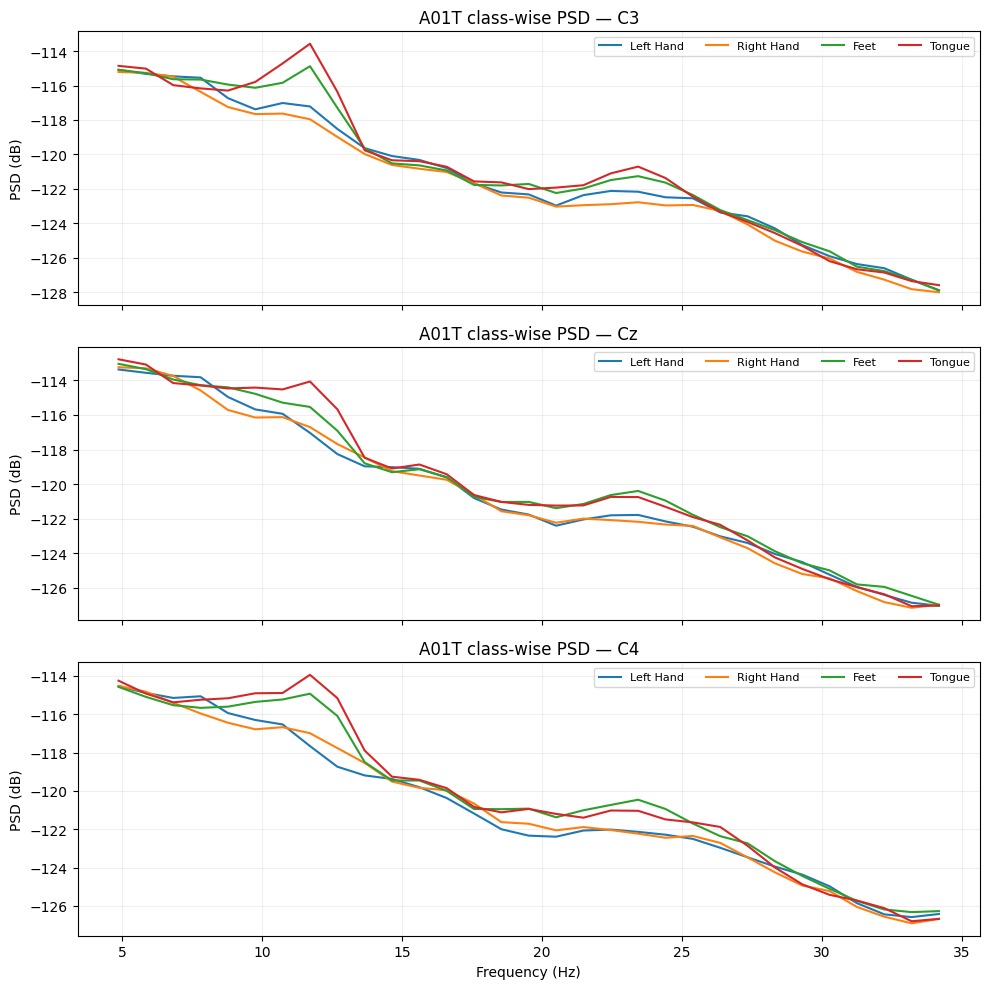

In [7]:
# ============================================================
# CELL 6 — FIXED C3/CZ/C4 CLASS-WISE PSD / ERD AUDIT
# ============================================================

MI_CH = {
    "C3": 7,
    "Cz": 9,
    "C4": 11
}

def welch_class_psd(X, y, ch, fs=FS):
    """
    X shape:
        (N_trials, 22, 1000)

    Returns:
        class name, frequency vector, mean PSD across trials
    """

    rows = []

    for c, name in enumerate(CLASS_NAMES):

        # (N_class_trials, N_time)
        xc = X[y == c, ch, :]

        if xc.shape[0] == 0:
            continue

        # Welch:
        # f -> (N_freq,)
        # p -> (N_trials, N_freq)
        f, p = signal.welch(
            xc,
            fs=fs,
            nperseg=min(256, xc.shape[-1]),
            axis=-1
        )

        # Keep MI-relevant frequencies
        mask = (f >= 4) & (f <= 35)

        # IMPORTANT:
        # frequency axis is axis=1, NOT axis=0
        p_mean = p[:, mask].mean(axis=0)

        rows.append(
            (
                name,
                f[mask],
                p_mean
            )
        )

    return rows


def plot_class_psd(X, y, title):

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(10, 10),
        sharex=True
    )

    for ax, (ch_name, ch) in zip(
        axes,
        MI_CH.items()
    ):

        for name, f, p in welch_class_psd(
            X,
            y,
            ch
        ):

            ax.plot(
                f,
                10 * np.log10(p + 1e-15),
                label=name,
                linewidth=1.5
            )

        ax.set_title(
            f"{title} — {ch_name}"
        )

        ax.set_ylabel(
            "PSD (dB)"
        )

        ax.grid(
            alpha=0.2
        )

        ax.legend(
            ncol=4,
            fontsize=8
        )

    axes[-1].set_xlabel(
        "Frequency (Hz)"
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# RUN A01T PSD AUDIT
# ------------------------------------------------------------

plot_class_psd(
    A01_XT,
    A01_yT,
    "A01T class-wise PSD"
)

In [8]:
# ============================================================
# CELL 7 — CONTROLLED WITHIN-SUBJECT A01T SPLIT
# ============================================================

def evaluate_lda(Xtr, ytr, Xva, yva, name):
    lda = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
    lda.fit(Xtr,ytr)
    pred=lda.predict(Xva)
    print(
        f"{name}: acc={accuracy_score(yva,pred)*100:.2f}% | "
        f"balanced={balanced_accuracy_score(yva,pred)*100:.2f}% | "
        f"kappa={cohen_kappa_score(yva,pred):.4f}"
    )
    return lda,pred

print("Within-subject check will use A01T only.")
idx_tr, idx_va = train_test_split(
    np.arange(len(A01_XT)),
    test_size=0.25,
    random_state=SEED,
    stratify=A01_yT
)
print("A01T split:", len(idx_tr), "train /", len(idx_va), "validation")


Within-subject check will use A01T only.
A01T split: 216 train / 72 validation


In [9]:
# ============================================================
# CELL 8 — FBCSP IMPLEMENTATION WITH TWO FEATURE DEFINITIONS
# ============================================================

class FBCSPDiagnostic:
    def __init__(self, m=4, regularization=0.0):
        self.m=m
        self.regularization=regularization
        self.W=[]
        self.meta=[]

    @staticmethod
    def cov_norm(x):
        c=x @ x.T
        tr=np.trace(c)
        return c/(tr+1e-12)

    def fit(self, Xfb, y):
        self.W=[]; self.meta=[]
        gi=0
        for b,(lo,hi) in enumerate(BANDS):
            Xb=Xfb[:,b]
            filters=[]
            for c in range(4):
                Rc=np.mean([self.cov_norm(x) for x in Xb[y==c]],axis=0)
                Rr=np.mean([self.cov_norm(x) for x in Xb[y!=c]],axis=0)
                if self.regularization>0:
                    I=np.eye(N_CHANNELS)
                    Rc=(1-self.regularization)*Rc+self.regularization*I/N_CHANNELS
                    Rr=(1-self.regularization)*Rr+self.regularization*I/N_CHANNELS
                vals, vecs=eigh(Rc+1e-10*np.eye(N_CHANNELS), Rr+1e-10*np.eye(N_CHANNELS))
                order=np.argsort(vals)[::-1]
                vals=vals[order]; vecs=vecs[:,order]
                W=vecs[:,:self.m]
                filters.append(W)
                for r in range(self.m):
                    self.meta.append({
                        "global_index":gi, "band":f"{lo}-{hi} Hz",
                        "band_index":b, "ovr_class":CLASS_NAMES[c],
                        "csp_rank":r+1, "eigenvalue":float(vals[r])
                    })
                    gi+=1
            self.W.append(np.hstack(filters))
        return self

    def _features_band(self, Xb, W, relative=True):
        Z=np.einsum("cf,nct->nft", W, Xb)
        v=np.var(Z,axis=-1)
        if relative:
            v=v/(np.sum(v,axis=1,keepdims=True)+1e-12)
        return np.log(v+1e-12)

    def transform(self, Xfb, relative=True):
        out=[]
        for b in range(len(BANDS)):
            out.append(self._features_band(Xfb[:,b], self.W[b], relative))
        return np.concatenate(out,axis=1)

def build_filter_bank(X, order=5):
    out=[]
    for lo,hi in BANDS:
        sos=signal.butter(order,[lo,hi],btype="bandpass",fs=FS,output="sos")
        out.append(signal.sosfiltfilt(sos,X,axis=-1).astype(np.float32))
    return np.stack(out,axis=1)


In [10]:
# ============================================================
# CELL 9 — TRAINING-ONLY NORMALIZATION + WITHIN-SUBJECT FBCSP
# ============================================================

def fit_norm(X):
    mu=X.mean(axis=(0,2),keepdims=True)
    sd=X.std(axis=(0,2),keepdims=True)+1e-6
    return mu.astype(np.float32),sd.astype(np.float32)

def norm(X,mu,sd):
    return ((X-mu)/sd).astype(np.float32)

# A01T-only fit for within-subject split
mu_t,sd_t=fit_norm(A01_XT[idx_tr])
Xtr_n=norm(A01_XT[idx_tr],mu_t,sd_t)
Xva_n=norm(A01_XT[idx_va],mu_t,sd_t)

print("within-subject z-score:")
print("max abs train mean:", float(np.max(np.abs(Xtr_n.mean(axis=(0,2))))))
print("max abs train std-1:", float(np.max(np.abs(Xtr_n.std(axis=(0,2))-1))))

Xtr_fb=build_filter_bank(Xtr_n)
Xva_fb=build_filter_bank(Xva_n)

fbcsp=FBCSPDiagnostic(m=4,regularization=0.0).fit(Xtr_fb,A01_yT[idx_tr])

Ftr_rel=fbcsp.transform(Xtr_fb,relative=True)
Fva_rel=fbcsp.transform(Xva_fb,relative=True)

Ftr_abs=fbcsp.transform(Xtr_fb,relative=False)
Fva_abs=fbcsp.transform(Xva_fb,relative=False)

print("candidate feature shape:", Ftr_rel.shape)

print("\nWITHIN-SUBJECT FBCSP+LDA — relative log-variance")
lda_rel,p_rel=evaluate_lda(Ftr_rel,A01_yT[idx_tr],Fva_rel,A01_yT[idx_va],"A01T split / relative")

print("\nWITHIN-SUBJECT FBCSP+LDA — absolute log-variance")
lda_abs,p_abs=evaluate_lda(Ftr_abs,A01_yT[idx_tr],Fva_abs,A01_yT[idx_va],"A01T split / absolute")


within-subject z-score:
max abs train mean: 1.7492858717105264e-08
max abs train std-1: 0.1296578049659729
candidate feature shape: (216, 160)

WITHIN-SUBJECT FBCSP+LDA — relative log-variance
A01T split / relative: acc=75.00% | balanced=75.00% | kappa=0.6667

WITHIN-SUBJECT FBCSP+LDA — absolute log-variance
A01T split / absolute: acc=76.39% | balanced=76.39% | kappa=0.6852


A01T -> A01E FBCSP+LDA
A01T → A01E: acc=75.69% | balanced=75.69% | kappa=0.6759


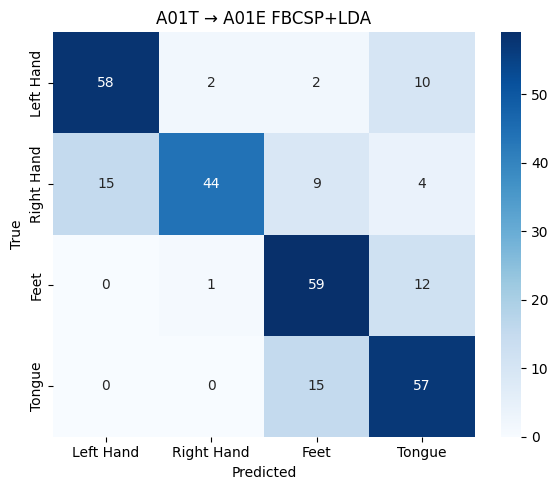

In [11]:
# ============================================================
# CELL 10 — CROSS-SESSION A01T → A01E CHECK
# ============================================================

# Fit normalization ONLY on A01T.
mu_cross, sd_cross = fit_norm(A01_XT)
XTn = norm(A01_XT,mu_cross,sd_cross)
XEn = norm(A01_XE,mu_cross,sd_cross)

XTfb=build_filter_bank(XTn)
XEfb=build_filter_bank(XEn)

cross_fbcsp=FBCSPDiagnostic(m=4,regularization=0.0).fit(XTfb,A01_yT)
F_T=cross_fbcsp.transform(XTfb,relative=True)
F_E=cross_fbcsp.transform(XEfb,relative=True)

print("A01T -> A01E FBCSP+LDA")
lda_cross,p_cross=evaluate_lda(
    F_T,A01_yT,F_E,A01_yE,"A01T → A01E"
)

cm=confusion_matrix(A01_yE,p_cross,labels=np.arange(4))
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
            xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES)
plt.title("A01T → A01E FBCSP+LDA")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()


LOADING BCI COMPETITION IV-2a
A01 labels: A01E.mat
A01: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.2s
A02 labels: A02E.mat
A02: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.1s
A03 labels: A03E.mat
A03: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.0s
A04 labels: A04E.mat
A04: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.0s
A05 labels: A05E.mat
A05: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.1s
A06 labels: A06E.mat
A06: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.1s
A07 labels: A07E.mat
A07: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.1s
A08 labels: A08E.mat
A08: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.1s
A09 labels: A09E.mat
A09: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.1s
ALL SUBJECTS LOADED SUCCESSFULLY

STRICT LOSO — A01
Training subjects: ['A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09']
Test subject: 

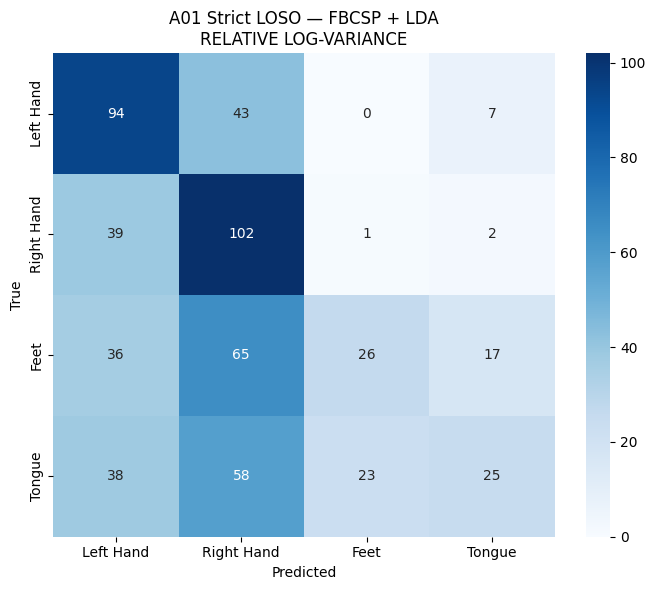


A01 STRICT LOSO — FBCSP + LDA
Feature type: ABSOLUTE LOG-VARIANCE
Train feature shape: (4608, 160)
Test feature shape: (576, 160)
A02-A09 → A01 (ABSOLUTE LOG-VARIANCE): acc=40.97% | balanced=40.97% | kappa=0.2130


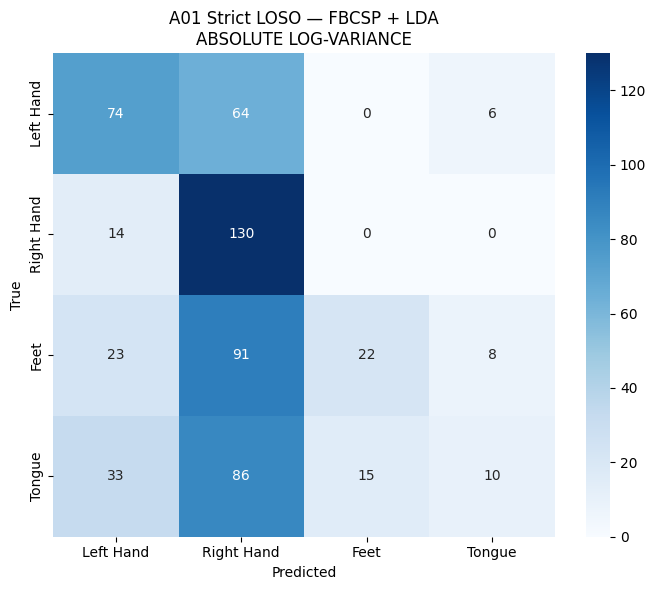

In [13]:
# ============================================================
# CELL 11 — STRICT LOSO A01 FBCSP DIAGNOSTIC
# SELF-CONTAINED VERSION
# ============================================================

def load_subject_2a(subject_id):
    """
    Load one BCI Competition IV-2a subject.

    T session:
        288 trials
        labels from GDF event codes 769–772

    E session:
        288 trials
        labels loaded from true_labels/

    Returns
    -------
    X : (576, 22, 1000)
    y : (576,)
    meta : DataFrame
    """

    # --------------------------------------------------------
    # TRAINING SESSION
    # --------------------------------------------------------
    t_path = DATA_ROOT / f"{subject_id}T.gdf"

    if not t_path.exists():
        raise FileNotFoundError(
            f"Missing training file:\n{t_path}"
        )

    _, eeg_T, meta_T = get_trial_metadata(
        t_path,
        "T"
    )

    X_T = epoch_from_continuous(
        eeg_T,
        meta_T
    )

    if len(meta_T) != 288:
        raise ValueError(
            f"{subject_id}T: expected 288 trials, "
            f"found {len(meta_T)}"
        )

    if X_T.shape != (288, N_CHANNELS, N_TIME):
        raise ValueError(
            f"{subject_id}T unexpected shape: {X_T.shape}"
        )

    y_T = np.array(
        [
            EVENT_TO_CLASS[int(code)]
            for code in meta_T["event_code"]
        ],
        dtype=np.int64
    )

    # --------------------------------------------------------
    # EVALUATION SESSION
    # --------------------------------------------------------
    e_path = DATA_ROOT / f"{subject_id}E.gdf"

    if not e_path.exists():
        raise FileNotFoundError(
            f"Missing evaluation file:\n{e_path}"
        )

    _, eeg_E, meta_E = get_trial_metadata(
        e_path,
        "E"
    )

    X_E = epoch_from_continuous(
        eeg_E,
        meta_E
    )

    if len(meta_E) != 288:
        raise ValueError(
            f"{subject_id}E: expected 288 trials, "
            f"found {len(meta_E)}"
        )

    if X_E.shape != (288, N_CHANNELS, N_TIME):
        raise ValueError(
            f"{subject_id}E unexpected shape: {X_E.shape}"
        )

    y_E = load_true_labels(
        subject_id,
        288
    )

    if len(y_E) != len(X_E):
        raise ValueError(
            f"{subject_id}E label mismatch: "
            f"{len(y_E)} labels vs {len(X_E)} epochs"
        )

    # --------------------------------------------------------
    # COMBINE T + E
    # --------------------------------------------------------
    X = np.concatenate(
        [X_T, X_E],
        axis=0
    ).astype(np.float32)

    y = np.concatenate(
        [y_T, y_E],
        axis=0
    ).astype(np.int64)

    meta = pd.concat(
        [
            meta_T.assign(session="T"),
            meta_E.assign(session="E")
        ],
        ignore_index=True
    )

    return X, y, meta


# ============================================================
# LOAD ALL 9 SUBJECTS
# ============================================================

def load_all_subjects_2a():

    subject_ids = [
        f"A{i:02d}"
        for i in range(1, 10)
    ]

    datasets = {}

    print("=" * 72)
    print("LOADING BCI COMPETITION IV-2a")
    print("=" * 72)

    for sid in subject_ids:

        start_time = time.time()

        X, y, meta = load_subject_2a(
            sid
        )

        counts = np.bincount(
            y,
            minlength=4
        )

        print(
            f"{sid}: "
            f"X={X.shape} | "
            f"class_counts={counts.tolist()} | "
            f"time={time.time() - start_time:.1f}s"
        )

        # ----------------------------------------------------
        # EXPECTED:
        # 576 total
        # 144/class
        # ----------------------------------------------------
        expected = np.array(
            [144, 144, 144, 144]
        )

        if not np.array_equal(
            counts,
            expected
        ):
            raise ValueError(
                f"{sid}: unexpected class distribution "
                f"{counts.tolist()}"
            )

        datasets[sid] = {
            "X": X,
            "y": y,
            "meta": meta
        }

    print("=" * 72)
    print("ALL SUBJECTS LOADED SUCCESSFULLY")
    print("=" * 72)

    return datasets


# ------------------------------------------------------------
# RUN LOADER
# ------------------------------------------------------------

ALL_SUBJECTS = load_all_subjects_2a()


# ============================================================
# STRICT LOSO — A01
# ============================================================

TEST_SUBJECT = "A01"

TRAIN_SUBJECTS = [
    sid
    for sid in ALL_SUBJECTS.keys()
    if sid != TEST_SUBJECT
]

print("\n" + "=" * 72)
print("STRICT LOSO — A01")
print("=" * 72)

print(
    "Training subjects:",
    TRAIN_SUBJECTS
)

print(
    "Test subject:",
    TEST_SUBJECT
)


# ------------------------------------------------------------
# TRAIN DATA = A02–A09
# ------------------------------------------------------------

X_loso = np.concatenate(
    [
        ALL_SUBJECTS[sid]["X"]
        for sid in TRAIN_SUBJECTS
    ],
    axis=0
)

y_loso = np.concatenate(
    [
        ALL_SUBJECTS[sid]["y"]
        for sid in TRAIN_SUBJECTS
    ],
    axis=0
)


# ------------------------------------------------------------
# TEST DATA = A01
# ------------------------------------------------------------

X_test_loso = ALL_SUBJECTS[
    TEST_SUBJECT
]["X"]

y_test_loso = ALL_SUBJECTS[
    TEST_SUBJECT
]["y"]


# ------------------------------------------------------------
# VERIFY SHAPES
# ------------------------------------------------------------

print(
    "\nTrain shape:",
    X_loso.shape
)

print(
    "Test shape:",
    X_test_loso.shape
)

print(
    "Train labels:",
    np.bincount(
        y_loso,
        minlength=4
    )
)

print(
    "Test labels:",
    np.bincount(
        y_test_loso,
        minlength=4
    )
)


assert X_loso.shape == (
    4608,
    22,
    1000
)

assert X_test_loso.shape == (
    576,
    22,
    1000
)


# ============================================================
# TRAINING-ONLY Z-SCORE
# ============================================================

mu_l, sd_l = fit_norm(
    X_loso
)

Xln = norm(
    X_loso,
    mu_l,
    sd_l
)

XTn = norm(
    X_test_loso,
    mu_l,
    sd_l
)

print("\n" + "=" * 72)
print("NORMALIZATION CHECK")
print("=" * 72)

print(
    "max |train mean|:",
    float(
        np.max(
            np.abs(
                Xln.mean(
                    axis=(0, 2)
                )
            )
        )
    )
)

print(
    "max |train std - 1|:",
    float(
        np.max(
            np.abs(
                Xln.std(
                    axis=(0, 2)
                ) - 1
            )
        )
    )
)


# ============================================================
# BUILD FILTER BANK
# ============================================================

print("\nBuilding 10-band filter bank...")

Xlfb = build_filter_bank(
    Xln
)

XTfb = build_filter_bank(
    XTn
)

print(
    "Filter-bank train:",
    Xlfb.shape
)

print(
    "Filter-bank test:",
    XTfb.shape
)


assert Xlfb.shape == (
    4608,
    10,
    22,
    1000
)

assert XTfb.shape == (
    576,
    10,
    22,
    1000
)


# ============================================================
# FIT FBCSP ONLY ON TRAINING SUBJECTS
# ============================================================

print("\n" + "=" * 72)
print("FITTING FBCSP ON A02–A09")
print("=" * 72)

loso_fbcsp = FBCSPDiagnostic(
    m=4,
    regularization=0.0
).fit(
    Xlfb,
    y_loso
)

print(
    "FBCSP candidate dimensions:",
    len(loso_fbcsp.meta)
)

assert len(loso_fbcsp.meta) == 160


# ============================================================
# COMPARE RELATIVE VS ABSOLUTE LOG-VARIANCE
# ============================================================

for relative in [True, False]:

    if relative:

        feature_name = (
            "RELATIVE LOG-VARIANCE"
        )

    else:

        feature_name = (
            "ABSOLUTE LOG-VARIANCE"
        )

    print("\n" + "=" * 72)
    print(
        f"A01 STRICT LOSO — FBCSP + LDA"
    )
    print(
        f"Feature type: {feature_name}"
    )
    print("=" * 72)

    # --------------------------------------------------------
    # TRAIN FEATURES
    # --------------------------------------------------------

    F_train = loso_fbcsp.transform(
        Xlfb,
        relative=relative
    )

    # --------------------------------------------------------
    # TEST FEATURES
    # --------------------------------------------------------

    F_test = loso_fbcsp.transform(
        XTfb,
        relative=relative
    )

    print(
        "Train feature shape:",
        F_train.shape
    )

    print(
        "Test feature shape:",
        F_test.shape
    )

    # --------------------------------------------------------
    # LDA
    # --------------------------------------------------------

    lda_model, predictions = evaluate_lda(
        F_train,
        y_loso,
        F_test,
        y_test_loso,
        f"A02-A09 → A01 ({feature_name})"
    )

    # --------------------------------------------------------
    # CONFUSION MATRIX
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_test_loso,
        predictions,
        labels=np.arange(4)
    )

    plt.figure(
        figsize=(7, 6)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )

    plt.title(
        f"A01 Strict LOSO — FBCSP + LDA\n"
        f"{feature_name}"
    )

    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "True"
    )

    plt.tight_layout()

    plt.show()

In [14]:
# ============================================================
# CELL 12 — FINAL DIAGNOSTIC SUMMARY
# ============================================================

print("=" * 72)
print("A01 FBCSP DIAGNOSTIC COMPLETE")
print("=" * 72)

print("""
The standalone LOSO loader has now completed successfully.

Expected:
    Training = A02-A09 = 4608 trials
    Testing  = A01     = 576 trials

The FBCSP pipeline uses:
    10 frequency bands
    4 OVR classes
    4 CSP vectors/class
    160 candidate dimensions

Next diagnostic experiments:
    1. A01T within-subject FBCSP
    2. A01T -> A01E cross-session FBCSP
    3. A02-A09 -> A01 strict LOSO FBCSP
    4. Relative vs absolute CSP features

Do NOT start CRNN/FBGAN from this cell.
""")

A01 FBCSP DIAGNOSTIC COMPLETE

The standalone LOSO loader has now completed successfully.

Expected:
    Training = A02-A09 = 4608 trials
    Testing  = A01     = 576 trials

The FBCSP pipeline uses:
    10 frequency bands
    4 OVR classes
    4 CSP vectors/class
    160 candidate dimensions

Next diagnostic experiments:
    1. A01T within-subject FBCSP
    2. A01T -> A01E cross-session FBCSP
    3. A02-A09 -> A01 strict LOSO FBCSP
    4. Relative vs absolute CSP features

Do NOT start CRNN/FBGAN from this cell.



## Expected next step

After these diagnostics, use the result to decide:

- **Data-alignment problem** → fix GDF/event/label extraction.
- **Within-subject good, LOSO poor** → keep preprocessing and focus on subject-invariant CRNN/domain adaptation.
- **Relative vs absolute FBCSP differs strongly** → use the paper-consistent feature definition consistently.
- **All classical checks are good but CRNN remains low** → inspect the exact CRNN-DF implementation and optimization.

The paper's reported values are still the final references:
- CRNN-DF: **63.52 ± 10.70%**
- CRNN-DF + 3,000 FBGAN samples: **72.82 ± 10.44%**

These numbers should be compared only after the evaluation protocol is fixed and the A01 test subject remains untouched during model selection.
